# Домашнее задание 4

**Курс:** Временные ряды  
**Студент:** Зехов Матвей Сергеевич

В решении я следую идее из лекций и семинаров: переводим временной ряд в табличную задачу, аккуратно создаём календарные, лаговые и оконные признаки без утечки будущего, затем сравниваем ML-модель с сезонным наивным прогнозом. Для многошагового прогноза вручную реализованы три стратегии из конспекта: recursive, direct и DirRec.

## 0. Импорты и настройки

Использую `ExtraTreesRegressor`: это нелинейная ансамблевая модель деревьев. Она хорошо работает с разномасштабными признаками без нормировки, умеет ловить взаимодействия календаря, лагов и погоды, а ещё достаточно быстро переобучается внутри expanding-window CV.

In [1]:
import os
import ssl
import urllib.parse
import urllib.request
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL

try:
    from statsmodels.tsa.seasonal import MSTL
except ImportError:
    MSTL = None

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 4)
pd.options.display.float_format = "{:,.4f}".format

RANDOM_STATE = 322
BASE_DIR = Path("/Users/maria/Desktop/work/HSE/additional/hse_githubs/Time series/2026-spring/homeworks/hw4")
DATA_PATH = BASE_DIR / "data.csv"
DESCRIPTION_PATH = BASE_DIR / "description.csv"

FULL_NAME = "Зехов Матвей Сергеевич"
SERIES_ID = str(len(FULL_NAME) % 3)
SERIES_ID

'1'

## 1. Загрузка данных

По правилу из задания берём ряд с номером `len(ФИО) % 3`. Для ФИО выше получается ряд `1`. Частота исходного датасета дневная: даты идут без пропусков от 2015-01-01 до 2017-09-17. Ресэмплирование не требуется.

In [2]:
raw = pd.read_csv(DATA_PATH)
description = pd.read_csv(DESCRIPTION_PATH)

raw["Date"] = pd.to_datetime(raw["Date"])
raw = raw.sort_values("Date").set_index("Date")

y = raw[SERIES_ID].astype(float).asfreq("D")
atm_info = description.loc[description["ATM_ID"].astype(str) == SERIES_ID].iloc[0]

print(f"ID ряда: {SERIES_ID}")
print(f"Адрес банкомата: {atm_info['ADDRESS']}")
print(f"Описание места: {atm_info['ADDR_ADDON']}")
print(f"Координаты: {atm_info['LATITUDE']:.6f}, {atm_info['LONGITUDE']:.6f}")
print(f"Период: {y.index.min().date()} -- {y.index.max().date()}")
print(f"Частота pandas: {pd.infer_freq(y.index)}")
print(f"Количество наблюдений: {len(y)}")
print(f"Пропусков: {y.isna().sum()}")
print(f"Нулевых значений: {(y == 0).sum()} ({(y == 0).mean():.2%})")

display(y.describe().to_frame("cash_out"))
display(raw.head())
display(description)

ID ряда: 1
Адрес банкомата: ул Вавилова, 57
Описание места: Дарвиновский музей
Координаты: 55.690624, 37.561489
Период: 2015-01-01 -- 2017-09-17
Частота pandas: D
Количество наблюдений: 991
Пропусков: 0
Нулевых значений: 10 (1.01%)


,cash_out
count,991.0000
mean,"252,826.4379"
std,"201,070.4883"
min,0.0000
25%,"119,500.0000"
50%,"196,300.0000"
75%,"325,650.0000"
max,"1,552,500.0000"


,1,0,2
Date,,,
2015-01-01,200.0000,0.0000,0.0000
2015-01-02,"101,200.0000",0.0000,"920,000.0000"
2015-01-03,"184,900.0000",0.0000,"1,943,200.0000"
2015-01-04,"66,200.0000",0.0000,"1,872,600.0000"
2015-01-05,"125,400.0000",0.0000,0.0000


,Unnamed: 0,ATM_ID,ADDRESS,ADDR_ADDON,LATITUDE,LONGITUDE
0,452,1,"ул Вавилова, 57",Дарвиновский музей,55.6906,37.5615
1,741,0,"ул Моховая, 9",Факультет журналистики МГУ им.М.В.Ломоносова,55.7546,37.6108
2,1563,2,"пл Манежная, 1, 2","ТК ""Охотный ряд""",55.7558,37.6146


Пропусков нет. Нулевые значения встречаются редко, поэтому не заменяю их искусственно: для банкомата это может быть реальным маленьким спросом/простоем, а ручная замена могла бы исказить задачу. Для ACF дополнительно посмотрю приращения и лог-приращения через `log1p`, чтобы нули не ломали логарифм.

In [3]:
is_regular = y.index.equals(pd.date_range(y.index.min(), y.index.max(), freq="D"))
print("Ряд регулярный дневной:", is_regular)

weekday_profile = y.groupby(y.index.day_name()).mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
display(weekday_profile.to_frame("weekday_mean"))

Ряд регулярный дневной: True


,weekday_mean
Date,
Monday,"208,518.4397"
Tuesday,"277,740.4255"
Wednesday,"290,166.6667"
Thursday,"324,902.1127"
Friday,"357,438.0282"
Saturday,"181,895.0704"
Sunday,"129,250.7042"


## 2. Эксплоративный анализ

Сначала посмотрим на сам ряд и автокорреляции. Я строю ACF для исходного ряда, первых разностей и лог-разностей: так легче отделить календарную структуру от медленных изменений уровня.

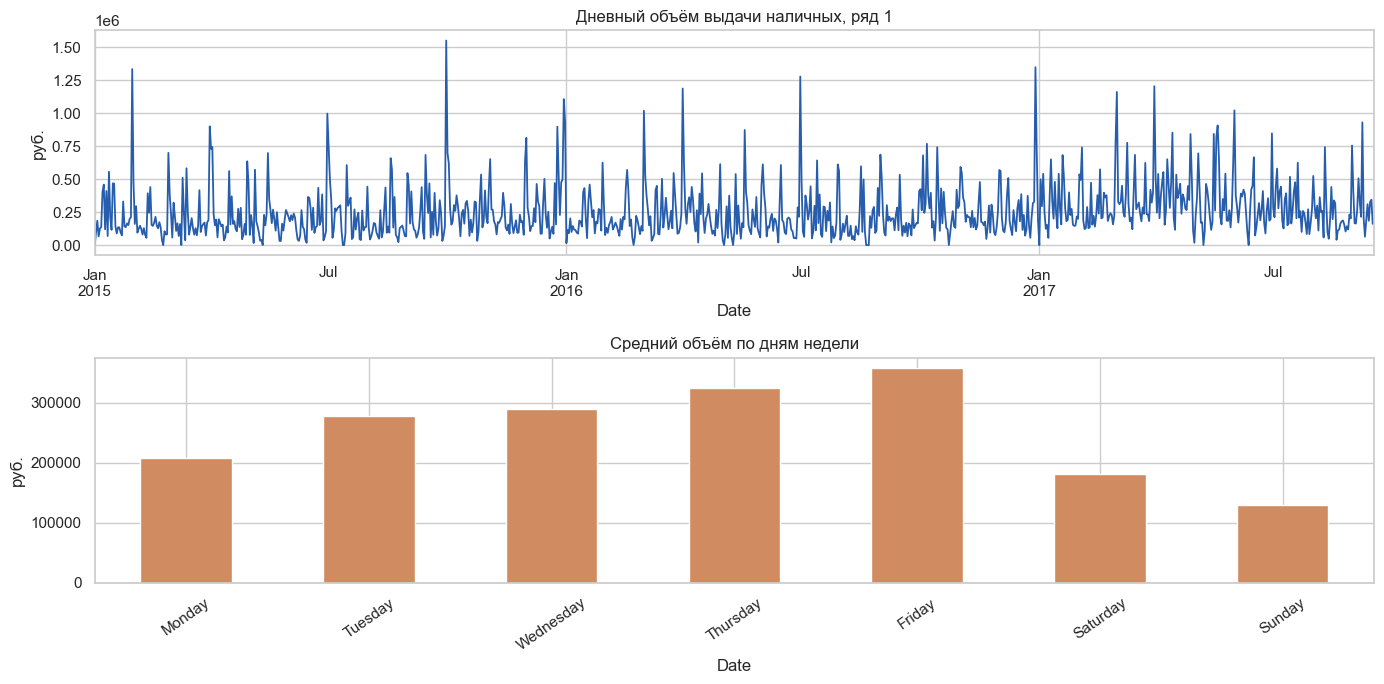

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
y.plot(ax=axes[0], color="#275DAD", lw=1.3)
axes[0].set_title("Дневный объём выдачи наличных, ряд 1")
axes[0].set_ylabel("руб.")

weekday_profile.plot(kind="bar", ax=axes[1], color="#D08C60")
axes[1].set_title("Средний объём по дням недели")
axes[1].set_ylabel("руб.")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

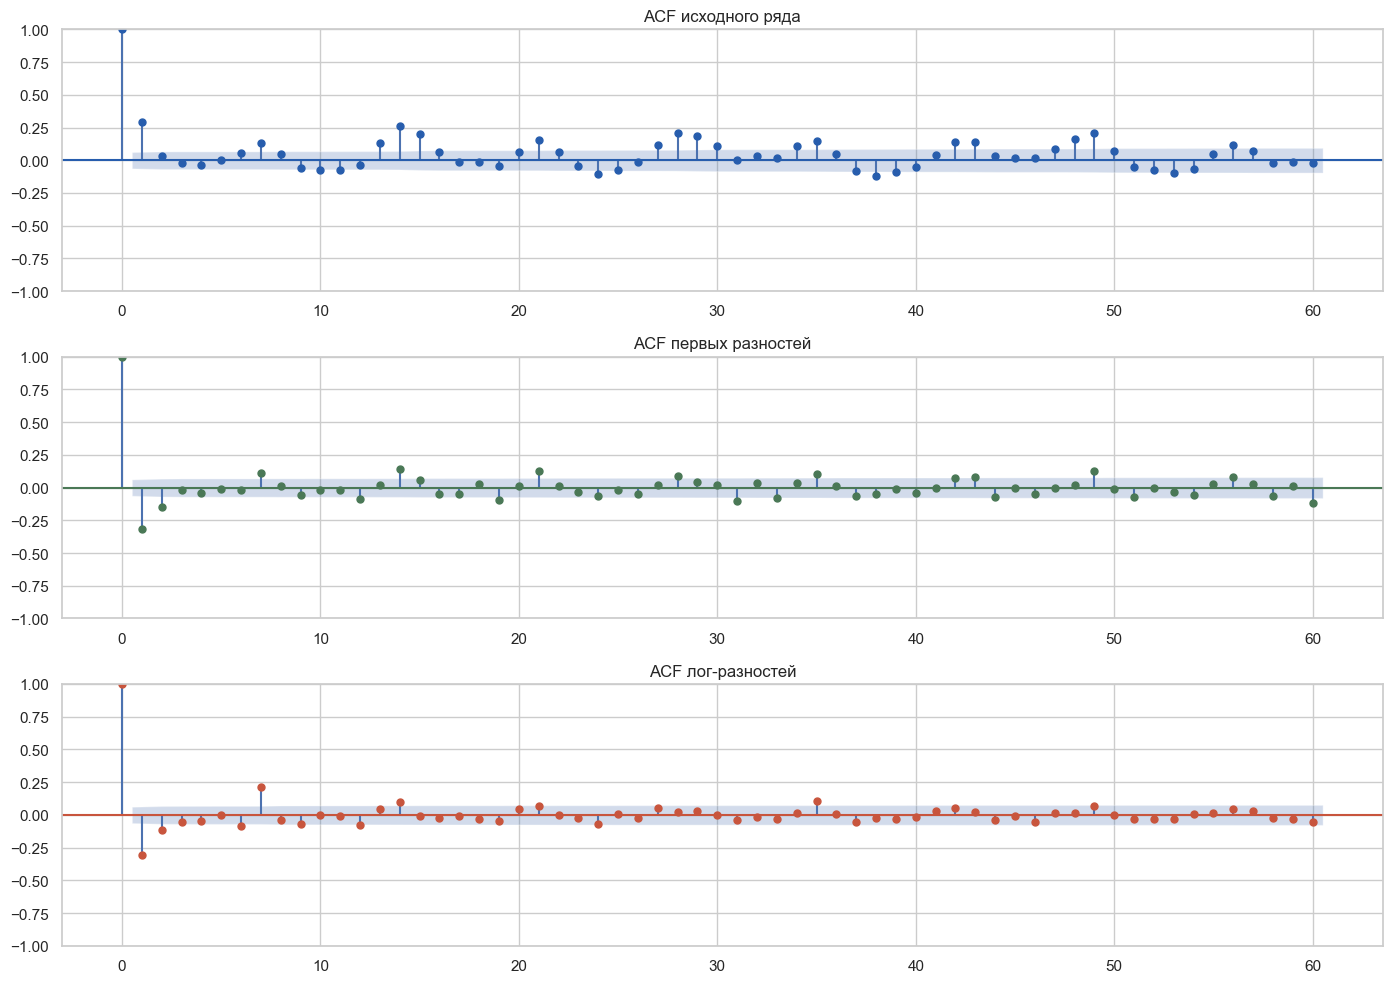

,lag,acf
0,1,0.2914
13,14,0.2641
48,49,0.2190
27,28,0.2144
14,15,0.2018
28,29,0.1884
47,48,0.1693
20,21,0.1562
34,35,0.1549
41,42,0.1471


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
plot_acf(y, lags=60, ax=axes[0], color="#275DAD")
axes[0].set_title("ACF исходного ряда")

plot_acf(y.diff().dropna(), lags=60, ax=axes[1], color="#4A7856")
axes[1].set_title("ACF первых разностей")

plot_acf(np.log1p(y).diff().dropna(), lags=60, ax=axes[2], color="#C8553D")
axes[2].set_title("ACF лог-разностей")
plt.tight_layout()
plt.show()

acf_values = [
    (lag, y.autocorr(lag=lag))
    for lag in range(1, 61)
]
acf_table = (
    pd.DataFrame(acf_values, columns=["lag", "acf"])
    .assign(abs_acf=lambda x: x["acf"].abs())
    .sort_values("abs_acf", ascending=False)
    .head(12)
    .drop(columns="abs_acf")
)
display(acf_table)

### Ответы по структуре ряда

**Тренд.** Явного устойчивого линейного тренда на всём интервале нет: средний уровень меняется участками, но ряд скорее колеблется вокруг локального уровня. Это значит, что для ML-модели важнее лаги и скользящие статистики, чем простая экстраполяция тренда.

**Сезонность.** Есть сильная недельная сезонность: средние значения по будням и выходным различаются, а ACF показывает заметные пики около кратных 7 дням. Для прогноза поэтому нужны признаки дня недели, лаги `7/14/21/28` и rolling-статистики.

**Цикличность.** У ряда видны более длинные повторяющиеся колебания около 4 недель. Это похоже не на экономический цикл, а на календарно-платёжную структуру спроса: зарплаты, авансы, привычки посещения музея/района. Поэтому добавляю признаки дня месяца, начала/конца месяца и сезонность через синусы/косинусы.

## 2.2. STL/MSTL

Периоды сезонности беру `7` и `28`: недельный период подтверждён профилем по дням недели и ACF, а 28 дней отражают месячно-платёжный ритм и повторение недельного паттерна на горизонте четырёх недель. Если установлен `MSTL`, разложение строится сразу для двух периодов; иначе показываю STL с основным недельным периодом.

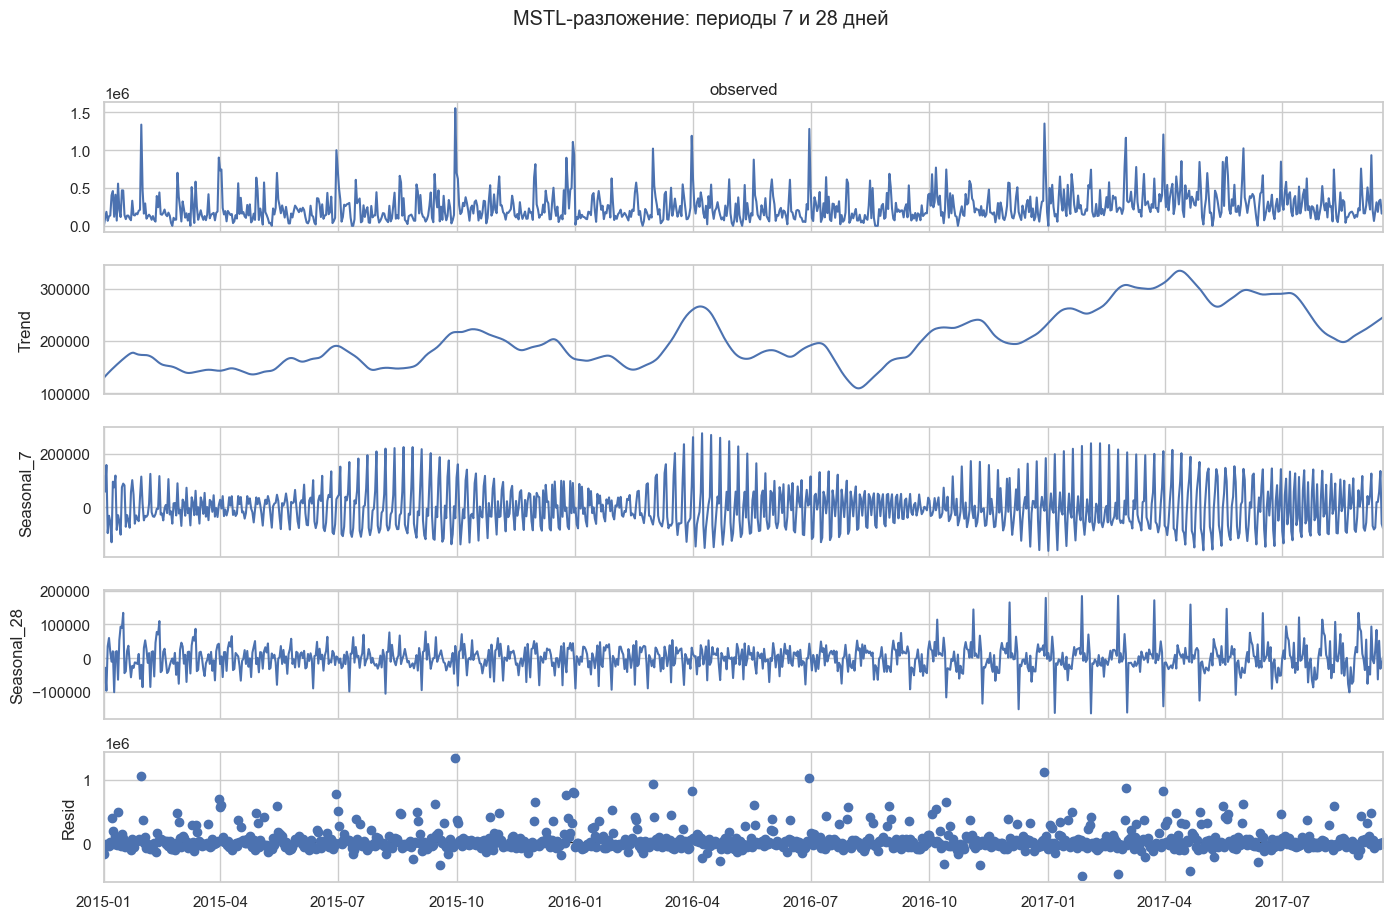

In [6]:
if MSTL is not None:
    decomposition = MSTL(y, periods=(7, 28), stl_kwargs={"robust": True}).fit()
    fig = decomposition.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle("MSTL-разложение: периоды 7 и 28 дней", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    decomposition = STL(y, period=7, robust=True).fit()
    fig = decomposition.plot()
    fig.set_size_inches(14, 8)
    fig.suptitle("STL-разложение: недельный период", y=1.02)
    plt.tight_layout()
    plt.show()

После разложения явные недельные колебания в остатке становятся слабее, значит выбранный период `7` хорошо объясняет регулярную часть ряда. Период `28` интерпретирую как календарно-платёжный: для банкомата важны повторения внутри месяца и четырёхнедельный горизонт, заданный в домашнем задании.

## 3. Выбор признаков

Собираю признаки в три группы, как обсуждалось в материалах курса про табличное представление временных рядов.

**Календарь:** день недели, выходной, понедельник/пятница, день месяца, месяц, квартал, начало/конец месяца, гармоники недели и года, праздники и соседние с праздниками дни. Эти признаки описывают недельную и календарную сезонность.

**Лаги таргета:** `1, 2, 3, 7, 14, 21, 28`. Короткие лаги ловят инерцию спроса, недельные лаги дают "последний такой же день недели".

**Оконные статистики:** среднее, стандартное отклонение, медиана, минимум и максимум по окнам `7, 14, 28`. Они описывают локальный уровень, волатильность и недавние экстремумы без использования будущих значений.

**Внешние переменные:** погодные данные Open-Meteo Archive для координат банкомата у Дарвиновского музея: средняя температура, осадки и снег. Идея: музейная/пешеходная локация зависит от погоды, а сильные осадки, мороз или снег могут менять поток людей и спрос на наличные. Для one-step считаю, что прогноз погоды на следующий день доступен; для multi-step будущую погоду заменяю простой климатологической оценкой по историческим данным, чтобы не было утечки фактического будущего.

In [7]:
def download_weather(latitude, longitude, start_date, end_date, target_path):
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": str(start_date),
        "end_date": str(end_date),
        "daily": "temperature_2m_mean,precipitation_sum,snowfall_sum",
        "timezone": "Europe/Moscow",
    }
    url = "https://archive-api.open-meteo.com/v1/archive?" + urllib.parse.urlencode(params)
    context = ssl._create_unverified_context()
    with urllib.request.urlopen(url, context=context, timeout=60) as response:
        payload = response.read()

    import json

    data = json.loads(payload)
    daily = pd.DataFrame(data["daily"]).rename(columns={"time": "Date"})
    daily.to_csv(target_path, index=False)
    return daily


def load_weather():
    candidates = [
        BASE_DIR / "hw4_weather.csv",
        Path.cwd() / "hw4_weather.csv",
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)

    target = Path.cwd() / "hw4_weather.csv"
    return download_weather(
        latitude=float(atm_info["LATITUDE"]),
        longitude=float(atm_info["LONGITUDE"]),
        start_date=y.index.min().date(),
        end_date=y.index.max().date(),
        target_path=target,
    )


def add_weather_derived(weather):
    weather = weather.copy()
    weather["Date"] = pd.to_datetime(weather["Date"])
    weather = weather.set_index("Date").sort_index()
    weather = weather.rename(
        columns={
            "temperature_2m_mean": "temp_mean",
            "precipitation_sum": "precipitation",
            "snowfall_sum": "snowfall",
        }
    )
    weather["is_freezing"] = (weather["temp_mean"] < 0).astype(int)
    weather["is_precip"] = (weather["precipitation"] > 0).astype(int)
    weather["bad_weather"] = (
        (weather["temp_mean"] <= -10)
        | (weather["precipitation"] >= 5)
        | (weather["snowfall"] >= 1)
    ).astype(int)
    return weather[["temp_mean", "precipitation", "snowfall", "is_freezing", "is_precip", "bad_weather"]]


weather_raw = load_weather()
weather_features = add_weather_derived(weather_raw)
display(weather_features.head())
display(weather_features.describe())

,temp_mean,precipitation,snowfall,is_freezing,is_precip,bad_weather
Date,,,,,,
2015-01-01,-1.3000,0.5000,0.4900,1,1,0
2015-01-02,0.8000,2.8000,1.8200,0,1,1
2015-01-03,1.0000,0.3000,0.2100,0,1,0
2015-01-04,-0.7000,2.5000,2.2400,1,1,1
2015-01-05,-10.4000,0.4000,0.5600,1,1,1


,temp_mean,precipitation,snowfall,is_freezing,is_precip,bad_weather
count,991.0000,991.0000,991.0000,991.0000,991.0000,991.0000
mean,6.3165,1.7510,0.3125,0.3078,0.5661,0.2331
std,10.3286,3.7866,0.9720,0.4618,0.4959,0.4230
min,-28.3000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,-1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,5.6000,0.2000,0.0000,0.0000,1.0000,0.0000
75%,15.6000,1.9000,0.0700,1.0000,1.0000,0.0000
max,25.0000,58.0000,13.7900,1.0000,1.0000,1.0000


In [8]:
def russian_holidays(years):
    dates = []
    for year in years:
        dates.extend(pd.date_range(f"{year}-01-01", f"{year}-01-08", freq="D"))
        dates.extend(
            [
                pd.Timestamp(f"{year}-02-23"),
                pd.Timestamp(f"{year}-03-08"),
                pd.Timestamp(f"{year}-05-01"),
                pd.Timestamp(f"{year}-05-09"),
                pd.Timestamp(f"{year}-06-12"),
                pd.Timestamp(f"{year}-11-04"),
            ]
        )
    return pd.DatetimeIndex(dates)


HOLIDAYS = russian_holidays(range(y.index.min().year, y.index.max().year + 1))
LAGS = [1, 2, 3, 7, 14, 21, 28]
ROLL_WINDOWS = [7, 14, 28]


def calendar_features(index, start_date):
    idx = pd.DatetimeIndex(index)
    normalized = idx.normalize()
    frame = pd.DataFrame(index=idx)

    frame["time_idx"] = (idx - pd.Timestamp(start_date)).days
    frame["dow"] = idx.dayofweek
    for dow in range(7):
        frame[f"dow_{dow}"] = (idx.dayofweek == dow).astype(int)
    frame["is_weekend"] = (idx.dayofweek >= 5).astype(int)
    frame["is_monday"] = (idx.dayofweek == 0).astype(int)
    frame["is_friday"] = (idx.dayofweek == 4).astype(int)
    frame["day"] = idx.day
    frame["month"] = idx.month
    frame["quarter"] = idx.quarter
    frame["is_month_start"] = idx.is_month_start.astype(int)
    frame["is_month_end"] = idx.is_month_end.astype(int)

    frame["week_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
    frame["week_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)
    frame["year_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    frame["year_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)

    frame["is_holiday"] = normalized.isin(HOLIDAYS).astype(int)
    frame["pre_holiday"] = (normalized + pd.Timedelta(days=1)).isin(HOLIDAYS).astype(int)
    frame["post_holiday"] = (normalized - pd.Timedelta(days=1)).isin(HOLIDAYS).astype(int)
    return frame


def make_exog_features(index, weather_frame, start_date):
    idx = pd.DatetimeIndex(index)
    calendar = calendar_features(idx, start_date=start_date)
    weather_part = weather_frame.reindex(idx)
    missing = int(weather_part.isna().any(axis=1).sum())
    if missing:
        raise ValueError(f"Weather data are missing for {missing} dates")
    return calendar.join(weather_part)


def lag_rolling_features(series, *, for_target):
    # If for_target=True, row t uses only observations up to t-1.
    frame = pd.DataFrame(index=series.index)
    for lag in LAGS:
        shift = lag if for_target else lag - 1
        frame[f"lag_{lag}"] = series.shift(shift)

    base = series.shift(1) if for_target else series
    for window in ROLL_WINDOWS:
        rolled = base.rolling(window)
        frame[f"roll_{window}_mean"] = rolled.mean()
        frame[f"roll_{window}_std"] = rolled.std()
        frame[f"roll_{window}_median"] = rolled.median()
        frame[f"roll_{window}_min"] = rolled.min()
        frame[f"roll_{window}_max"] = rolled.max()
    return frame


def history_row_from_series(series, row_index):
    values = series.dropna()
    row = {}
    for lag in LAGS:
        row[f"lag_{lag}"] = values.iloc[-lag] if len(values) >= lag else np.nan

    for window in ROLL_WINDOWS:
        tail = values.iloc[-window:]
        row[f"roll_{window}_mean"] = tail.mean()
        row[f"roll_{window}_std"] = tail.std(ddof=1)
        row[f"roll_{window}_median"] = tail.median()
        row[f"roll_{window}_min"] = tail.min()
        row[f"roll_{window}_max"] = tail.max()
    return pd.DataFrame([row], index=pd.DatetimeIndex([row_index]))


full_exog = make_exog_features(y.index, weather_features, start_date=y.index.min())
feature_preview = full_exog.join(lag_rolling_features(y, for_target=True)).dropna()
print(f"Всего признаков после объединения: {feature_preview.shape[1]}")
display(feature_preview.head())

Всего признаков после объединения: 52


,time_idx,dow,dow_0,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,is_weekend,...,roll_14_mean,roll_14_std,roll_14_median,roll_14_min,roll_14_max,roll_28_mean,roll_28_std,roll_28_median,roll_28_min,roll_28_max
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-29,28,3,0,0,0,1,0,0,0,0,...,"195,150.0000","130,615.2409","142,250.0000","73,600.0000","468,600.0000","203,307.1429","150,375.5371","139,450.0000",200.0000,"557,100.0000"
2015-01-30,29,4,0,0,0,0,1,0,0,0,...,"176,778.5714","104,715.1681","142,250.0000","73,600.0000","466,700.0000","210,850.0000","145,011.5691","142,250.0000","66,200.0000","557,100.0000"
2015-01-31,30,5,0,0,0,0,0,1,0,1,...,"238,857.1429","321,997.6367","142,250.0000","73,600.0000","1,335,800.0000","254,942.8571","255,807.9378","147,150.0000","66,200.0000","1,335,800.0000"
2015-02-01,31,6,0,0,0,0,0,0,1,1,...,"262,342.8571","326,374.4398","147,100.0000","73,600.0000","1,335,800.0000","265,164.2857","258,608.1309","147,150.0000","66,200.0000","1,335,800.0000"
2015-02-02,32,0,1,0,0,0,0,0,0,0,...,"267,521.4286","323,970.2222","156,500.0000","73,600.0000","1,335,800.0000","268,550.0000","256,518.9265","156,500.0000","69,100.0000","1,335,800.0000"


## 4. Одношаговое прогнозирование

Формируем таблицу так, чтобы строка с датой `t` содержала только информацию, доступную до прогноза `y_t`: календарь даты `t`, погодный прогноз/наблюдение для даты `t` и лаги/окна, рассчитанные по значениям до `t-1`. Разбивка train/test упорядоченная, 80/20.

In [9]:
def wape(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    return np.abs(actual - forecast).sum() / np.abs(actual).sum()


def make_one_step_table(series, exog):
    table = exog.join(lag_rolling_features(series, for_target=True))
    table["target"] = series
    return table.dropna()


one_step_table = make_one_step_table(y, full_exog)
X_one = one_step_table.drop(columns="target")
y_one = one_step_table["target"]

split = int(len(one_step_table) * 0.8)
X_train_one, X_test_one = X_one.iloc[:split], X_one.iloc[split:]
y_train_one, y_test_one = y_one.iloc[:split], y_one.iloc[split:]

print("Размер train:", X_train_one.shape)
print("Размер test:", X_test_one.shape)
print("Train:", X_train_one.index.min().date(), "--", X_train_one.index.max().date())
print("Test:", X_test_one.index.min().date(), "--", X_test_one.index.max().date())

Размер train: (770, 52)
Размер test: (193, 52)
Train: 2015-01-29 -- 2017-03-08
Test: 2017-03-09 -- 2017-09-17


In [10]:
def make_model(params):
    return ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **params,
    )


def expanding_window_cv(X, target, param_grid, min_train_size, val_size=28, step=28):
    rows = []
    starts = list(range(min_train_size, len(X) - val_size + 1, step))
    for params in param_grid:
        fold_scores = []
        for start in starts:
            train_idx = np.arange(0, start)
            val_idx = np.arange(start, start + val_size)
            model = make_model(params)
            model.fit(X.iloc[train_idx], target.iloc[train_idx])
            forecast = np.clip(model.predict(X.iloc[val_idx]), 0, None)
            fold_scores.append(wape(target.iloc[val_idx], forecast))
        rows.append(
            {
                "params": params,
                "mean_wape": np.mean(fold_scores),
                "std_wape": np.std(fold_scores),
                "folds": len(fold_scores),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_wape").reset_index(drop=True)


ONE_STEP_GRID = [
    {"n_estimators": 200, "min_samples_leaf": 3, "max_features": 0.8, "max_depth": None},
    {"n_estimators": 200, "min_samples_leaf": 7, "max_features": 0.8, "max_depth": None},
    {"n_estimators": 200, "min_samples_leaf": 5, "max_features": 0.6, "max_depth": 8},
]

cv_one = expanding_window_cv(
    X_train_one,
    y_train_one,
    ONE_STEP_GRID,
    min_train_size=int(len(X_train_one) * 0.5),
    val_size=28,
    step=28,
)
display(cv_one)

best_one_params = cv_one.loc[0, "params"]
best_one_params

,params,mean_wape,std_wape,folds
0,"{'n_estimators': 200, 'min_samples_leaf': 5, '...",0.4857,0.0884,13
1,"{'n_estimators': 200, 'min_samples_leaf': 7, '...",0.4904,0.0926,13
2,"{'n_estimators': 200, 'min_samples_leaf': 3, '...",0.4913,0.0798,13


{'n_estimators': 200,
 'min_samples_leaf': 5,
 'max_features': 0.6,
 'max_depth': 8}

In [11]:
one_step_model = make_model(best_one_params)
one_step_model.fit(X_train_one, y_train_one)

one_step_forecast = pd.Series(
    np.clip(one_step_model.predict(X_test_one), 0, None),
    index=y_test_one.index,
    name="ExtraTrees one-step",
)
one_step_naive = X_test_one["lag_7"].rename("seasonal naive")

one_step_metrics = pd.DataFrame(
    {
        "model": ["ExtraTrees one-step", "Seasonal naive, lag 7"],
        "WAPE": [
            wape(y_test_one, one_step_forecast),
            wape(y_test_one, one_step_naive),
        ],
    }
).sort_values("WAPE")
display(one_step_metrics)

importance = (
    pd.Series(one_step_model.feature_importances_, index=X_train_one.columns)
    .sort_values(ascending=False)
    .head(15)
)
display(importance.to_frame("importance"))

,model,WAPE
0,ExtraTrees one-step,0.3826
1,"Seasonal naive, lag 7",0.5827


,importance
is_month_end,0.1688
is_weekend,0.1556
is_month_start,0.0812
lag_1,0.0774
day,0.0584
week_sin,0.0473
dow,0.0343
is_freezing,0.0277
lag_3,0.0262
year_cos,0.0259


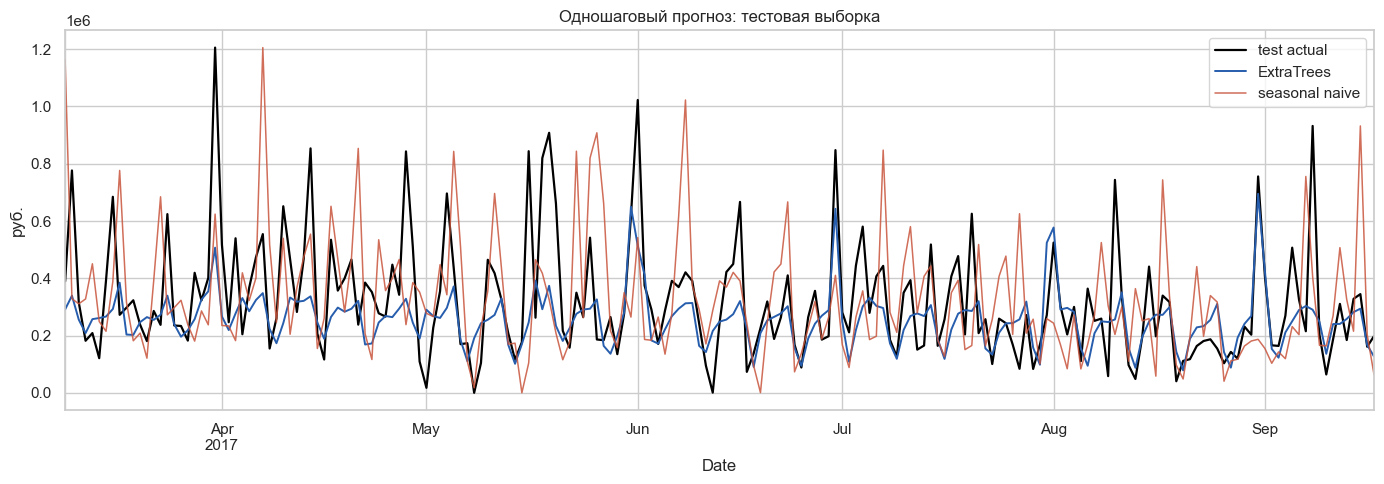

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
y_test_one.plot(ax=ax, color="black", lw=1.6, label="test actual")
one_step_forecast.plot(ax=ax, color="#275DAD", lw=1.4, label="ExtraTrees")
one_step_naive.plot(ax=ax, color="#C8553D", lw=1.1, alpha=0.85, label="seasonal naive")
ax.set_title("Одношаговый прогноз: тестовая выборка")
ax.set_ylabel("руб.")
ax.legend()
plt.tight_layout()
plt.show()

ML-модель лучше сезонной наивной модели на тесте. Это ожидаемо: наивная модель использует только значение недельной давности, а `ExtraTrees` дополнительно учитывает короткую инерцию, 2--4-недельные лаги, локальный уровень, календарь и погоду.

## 5. Многошаговое прогнозирование

Горизонт из задания: 4 недели, то есть `28` дней. Последние 28 наблюдений оставляю на тест, всё до них использую как train.

Внешняя переменная требует отдельной аккуратности: фактическая погода в будущем неизвестна. Поэтому для каждого будущего дня строю простой прогноз погоды по средним историческим значениям для соответствующего дня года, а при нехватке данных использую среднее по месяцу. Это не идеальная модель погоды, зато она не подглядывает в тест.

In [13]:
HORIZON = 28
multi_train_y = y.iloc[:-HORIZON]
multi_test_y = y.iloc[-HORIZON:]

multi_train_exog = full_exog.loc[multi_train_y.index]
multi_test_dates = multi_test_y.index

print("Train:", multi_train_y.index.min().date(), "--", multi_train_y.index.max().date(), len(multi_train_y))
print("Test :", multi_test_y.index.min().date(), "--", multi_test_y.index.max().date(), len(multi_test_y))

Train: 2015-01-01 -- 2017-08-20 963
Test : 2017-08-21 -- 2017-09-17 28


In [14]:
BASIC_WEATHER_COLS = ["temp_mean", "precipitation", "snowfall"]


def derive_weather_columns(frame):
    frame = frame.copy()
    frame["is_freezing"] = (frame["temp_mean"] < 0).astype(int)
    frame["is_precip"] = (frame["precipitation"] > 0).astype(int)
    frame["bad_weather"] = (
        (frame["temp_mean"] <= -10)
        | (frame["precipitation"] >= 5)
        | (frame["snowfall"] >= 1)
    ).astype(int)
    return frame[["temp_mean", "precipitation", "snowfall", "is_freezing", "is_precip", "bad_weather"]]


def weather_climatology_forecast(weather_history, future_index):
    future_index = pd.DatetimeIndex(future_index)
    history = weather_history[BASIC_WEATHER_COLS].copy()
    by_doy = history.groupby(history.index.dayofyear).mean()
    by_month = history.groupby(history.index.month).mean()
    overall = history.mean()

    rows = []
    for date in future_index:
        if date.dayofyear in by_doy.index:
            row = by_doy.loc[date.dayofyear]
        elif date.month in by_month.index:
            row = by_month.loc[date.month]
        else:
            row = overall
        rows.append(row)

    forecast = pd.DataFrame(rows, index=future_index)
    return derive_weather_columns(forecast)


future_weather_forecast = weather_climatology_forecast(
    weather_features.loc[: multi_train_y.index[-1]],
    multi_test_dates,
)
future_exog = make_exog_features(multi_test_dates, future_weather_forecast, start_date=y.index.min())
display(future_weather_forecast.head())

,temp_mean,precipitation,snowfall,is_freezing,is_precip,bad_weather
Date,,,,,,
2017-08-21,18.1500,3.6500,0.0000,0,1,0
2017-08-22,18.9500,0.0500,0.0000,0,1,0
2017-08-23,19.0500,0.1500,0.0000,0,1,0
2017-08-24,18.2500,0.0000,0.0000,0,0,0
2017-08-25,17.7000,1.7500,0.0000,0,1,0


### Общие функции для многошаговых стратегий

Ниже все стратегии реализованы вручную.

**Recursive:** обучаем одну one-step модель, затем каждый новый прогноз добавляем в историю и используем как лаг для следующего шага.

**Direct:** для каждого горизонта `h` обучаем отдельную модель `y_{t+h}` на признаках, известных в момент `t`, и календаре/погодном прогнозе целевой даты.

**DirRec:** тоже обучаем отдельную модель для каждого `h`, но дополнительно даём ей предыдущие будущие значения. На обучении это фактические `y_{t+1}, ..., y_{t+h-1}`, на прогнозе - уже полученные прогнозы.

In [15]:
def make_direct_table(series, exog, horizon):
    origin_features = lag_rolling_features(series, for_target=False)
    target_exog = exog.shift(-horizon)
    target = series.shift(-horizon).rename("target")
    table = origin_features.join(target_exog).join(target).dropna()
    return table.drop(columns="target"), table["target"]


def make_dirrec_table(series, exog, horizon):
    X, target = make_direct_table(series, exog, horizon)
    for previous_horizon in range(1, horizon):
        X[f"previous_target_h{previous_horizon}"] = series.shift(-previous_horizon).reindex(X.index)
    table = X.join(target.rename("target")).dropna()
    return table.drop(columns="target"), table["target"]


def recursive_forecast(train_series, train_exog, future_index, future_exog_frame, params):
    table = make_one_step_table(train_series, train_exog)
    X_train = table.drop(columns="target")
    target = table["target"]
    model = make_model(params)
    model.fit(X_train, target)

    history = train_series.copy()
    preds = []
    for date in pd.DatetimeIndex(future_index):
        row = future_exog_frame.loc[[date]].join(history_row_from_series(history, date))
        row = row.reindex(columns=X_train.columns)
        pred = float(np.clip(model.predict(row)[0], 0, None))
        preds.append(pred)
        history.loc[date] = pred
    return pd.Series(preds, index=pd.DatetimeIndex(future_index), name="recursive")


def direct_forecast(train_series, train_exog, future_index, future_exog_frame, params):
    preds = []
    for horizon, date in enumerate(pd.DatetimeIndex(future_index), start=1):
        X_train, target = make_direct_table(train_series, train_exog, horizon)
        model = make_model(params)
        model.fit(X_train, target)
        row = history_row_from_series(train_series, date).join(future_exog_frame.loc[[date]])
        row = row.reindex(columns=X_train.columns)
        pred = float(np.clip(model.predict(row)[0], 0, None))
        preds.append(pred)
    return pd.Series(preds, index=pd.DatetimeIndex(future_index), name="direct")


def dirrec_forecast(train_series, train_exog, future_index, future_exog_frame, params):
    preds = []
    previous_predictions = {}
    for horizon, date in enumerate(pd.DatetimeIndex(future_index), start=1):
        X_train, target = make_dirrec_table(train_series, train_exog, horizon)
        model = make_model(params)
        model.fit(X_train, target)

        row = history_row_from_series(train_series, date).join(future_exog_frame.loc[[date]])
        for previous_horizon in range(1, horizon):
            row[f"previous_target_h{previous_horizon}"] = previous_predictions[previous_horizon]
        row = row.reindex(columns=X_train.columns)
        pred = float(np.clip(model.predict(row)[0], 0, None))
        preds.append(pred)
        previous_predictions[horizon] = pred
    return pd.Series(preds, index=pd.DatetimeIndex(future_index), name="dirrec")


def seasonal_naive_multistep(train_series, future_index, season_length=7):
    pattern = train_series.iloc[-season_length:].to_numpy()
    repeated = np.resize(pattern, len(future_index))
    return pd.Series(repeated, index=pd.DatetimeIndex(future_index), name="seasonal_naive")

### Кросс-валидация для многошаговых стратегий

Для каждой стратегии подбираю параметры на expanding-window CV внутри train. Сетка компактная, потому что direct и DirRec обучают по модели на каждый горизонт.

In [16]:
MULTI_GRID = [
    {"n_estimators": 80, "min_samples_leaf": 3, "max_features": 0.8, "max_depth": None},
    {"n_estimators": 80, "min_samples_leaf": 7, "max_features": 0.8, "max_depth": None},
]


def multi_step_cv(strategy_name, param_grid, origin_positions):
    strategy_fn = {
        "recursive": recursive_forecast,
        "direct": direct_forecast,
        "dirrec": dirrec_forecast,
    }[strategy_name]

    rows = []
    for params in param_grid:
        scores = []
        for origin_pos in origin_positions:
            cv_train_y = multi_train_y.iloc[:origin_pos]
            cv_val_y = multi_train_y.iloc[origin_pos : origin_pos + HORIZON]
            cv_train_exog = full_exog.loc[cv_train_y.index]
            cv_future_weather = weather_climatology_forecast(
                weather_features.loc[: cv_train_y.index[-1]],
                cv_val_y.index,
            )
            cv_future_exog = make_exog_features(
                cv_val_y.index,
                cv_future_weather,
                start_date=y.index.min(),
            )
            forecast = strategy_fn(
                cv_train_y,
                cv_train_exog,
                cv_val_y.index,
                cv_future_exog,
                params,
            )
            scores.append(wape(cv_val_y, forecast))
        rows.append(
            {
                "strategy": strategy_name,
                "params": params,
                "mean_wape": np.mean(scores),
                "std_wape": np.std(scores),
                "folds": len(scores),
            }
        )
    return pd.DataFrame(rows).sort_values("mean_wape").reset_index(drop=True)


origin_positions = [int(len(multi_train_y) * 0.68), int(len(multi_train_y) * 0.82)]
cv_recursive = multi_step_cv("recursive", MULTI_GRID, origin_positions)
cv_direct = multi_step_cv("direct", MULTI_GRID, origin_positions)
cv_dirrec = multi_step_cv("dirrec", MULTI_GRID, origin_positions)

multi_cv = pd.concat([cv_recursive, cv_direct, cv_dirrec], ignore_index=True)
display(multi_cv.sort_values(["strategy", "mean_wape"]))

best_multi_params = {
    strategy: multi_cv.loc[multi_cv["strategy"] == strategy].sort_values("mean_wape").iloc[0]["params"]
    for strategy in ["recursive", "direct", "dirrec"]
}
best_multi_params

,strategy,params,mean_wape,std_wape,folds
2,direct,"{'n_estimators': 80, 'min_samples_leaf': 7, 'm...",0.4627,0.0321,2
3,direct,"{'n_estimators': 80, 'min_samples_leaf': 3, 'm...",0.4660,0.0585,2
4,dirrec,"{'n_estimators': 80, 'min_samples_leaf': 3, 'm...",0.4361,0.0442,2
5,dirrec,"{'n_estimators': 80, 'min_samples_leaf': 7, 'm...",0.4490,0.0265,2
0,recursive,"{'n_estimators': 80, 'min_samples_leaf': 3, 'm...",0.4169,0.0269,2
1,recursive,"{'n_estimators': 80, 'min_samples_leaf': 7, 'm...",0.4678,0.0440,2


{'recursive': {'n_estimators': 80,
  'min_samples_leaf': 3,
  'max_features': 0.8,
  'max_depth': None},
 'direct': {'n_estimators': 80,
  'min_samples_leaf': 7,
  'max_features': 0.8,
  'max_depth': None},
 'dirrec': {'n_estimators': 80,
  'min_samples_leaf': 3,
  'max_features': 0.8,
  'max_depth': None}}

### 5.2. Рекурсивная стратегия

Обучается одна модель для следующего дня. После прогноза на первый день значение добавляется в историю, поэтому лаги для второго дня уже используют прогноз. Это просто и устойчиво, но ошибки могут накапливаться по горизонту.

In [17]:
recursive_pred = recursive_forecast(
    multi_train_y,
    multi_train_exog,
    multi_test_dates,
    future_exog,
    best_multi_params["recursive"],
)
print("Recursive WAPE:", wape(multi_test_y, recursive_pred))

Recursive WAPE: 0.3139058304433704


### 5.3. Прямая стратегия

Для каждого горизонта от 1 до 28 обучается своя модель. Такая стратегия не накапливает ошибки рекурсивно, но каждая модель видит меньше релевантных примеров для своего конкретного горизонта.

In [18]:
direct_pred = direct_forecast(
    multi_train_y,
    multi_train_exog,
    multi_test_dates,
    future_exog,
    best_multi_params["direct"],
)
print("Direct WAPE:", wape(multi_test_y, direct_pred))

Direct WAPE: 0.31669457455005134


### 5.4. DirRec

DirRec совмещает идеи recursive и direct: модель для горизонта `h` обучается отдельно, но также получает предыдущие будущие значения как признаки. На прогнозе вместо будущих фактов подаются уже построенные прогнозы.

In [19]:
dirrec_pred = dirrec_forecast(
    multi_train_y,
    multi_train_exog,
    multi_test_dates,
    future_exog,
    best_multi_params["dirrec"],
)
print("DirRec WAPE:", wape(multi_test_y, dirrec_pred))

DirRec WAPE: 0.3093940293820486


### 5.5. Собственная стратегия: ансамбль стратегий

В качестве дополнительной стратегии беру простой равновесный ансамбль recursive, direct и DirRec. Идея ансамбля: разные стратегии ошибаются по-разному, а усреднение часто снижает дисперсию прогноза и делает результат менее зависимым от одной конкретной схемы.

In [20]:
ensemble_pred = pd.concat([recursive_pred, direct_pred, dirrec_pred], axis=1).mean(axis=1)
ensemble_pred.name = "ensemble"
print("Ensemble WAPE:", wape(multi_test_y, ensemble_pred))

Ensemble WAPE: 0.3000456265150342


### 5.6. Сезонный наивный бенчмарк

Для дневных данных с недельной сезонностью прогноз на будущий понедельник равен последнему известному понедельнику, на вторник - последнему вторнику и так далее. На горизонте 28 дней это просто повтор последних 7 значений train четыре раза.

In [21]:
multi_naive = seasonal_naive_multistep(multi_train_y, multi_test_dates, season_length=7)
print("Seasonal naive WAPE:", wape(multi_test_y, multi_naive))

Seasonal naive WAPE: 0.45984544387100296


### 5.7. Итоги многошагового прогноза

Сравним все стратегии на последнем 28-дневном тесте.

In [22]:
multi_forecasts = pd.concat(
    [
        multi_test_y.rename("actual"),
        recursive_pred,
        direct_pred,
        dirrec_pred,
        ensemble_pred,
        multi_naive,
    ],
    axis=1,
)

multi_metrics = pd.DataFrame(
    {
        "strategy": ["recursive", "direct", "dirrec", "ensemble", "seasonal_naive"],
        "WAPE": [
            wape(multi_test_y, recursive_pred),
            wape(multi_test_y, direct_pred),
            wape(multi_test_y, dirrec_pred),
            wape(multi_test_y, ensemble_pred),
            wape(multi_test_y, multi_naive),
        ],
    }
).sort_values("WAPE")

display(multi_metrics)
display(multi_forecasts.head(10))

,strategy,WAPE
3,ensemble,0.3000
2,dirrec,0.3094
0,recursive,0.3139
1,direct,0.3167
4,seasonal_naive,0.4598


,actual,recursive,direct,dirrec,ensemble,seasonal_naive
Date,,,,,,
2017-08-21,"117,500.0000","221,071.7708","195,882.8349","203,092.1458","206,682.2505","194,300.0000"
2017-08-22,"163,500.0000","265,160.8333","278,130.1884","324,943.7917","289,411.6045","440,800.0000"
2017-08-23,"181,000.0000","220,080.4792","241,043.2551","233,419.5833","231,514.4392","197,300.0000"
2017-08-24,"186,900.0000","328,785.5417","339,909.2680","287,704.0833","318,799.6310","339,500.0000"
2017-08-25,"154,700.0000","353,210.4583","311,131.7003","305,362.9167","323,235.0251","317,000.0000"
2017-08-26,"103,200.0000","124,946.2083","185,817.3418","129,369.7500","146,711.1000","40,500.0000"
2017-08-27,"142,900.0000","122,785.7083","126,773.3416","132,873.7083","127,477.5861","111,500.0000"
2017-08-28,"119,200.0000","216,707.3542","221,646.7007","215,060.9792","217,805.0114","194,300.0000"
2017-08-29,"231,300.0000","281,951.5625","275,094.6433","271,772.7917","276,272.9992","440,800.0000"


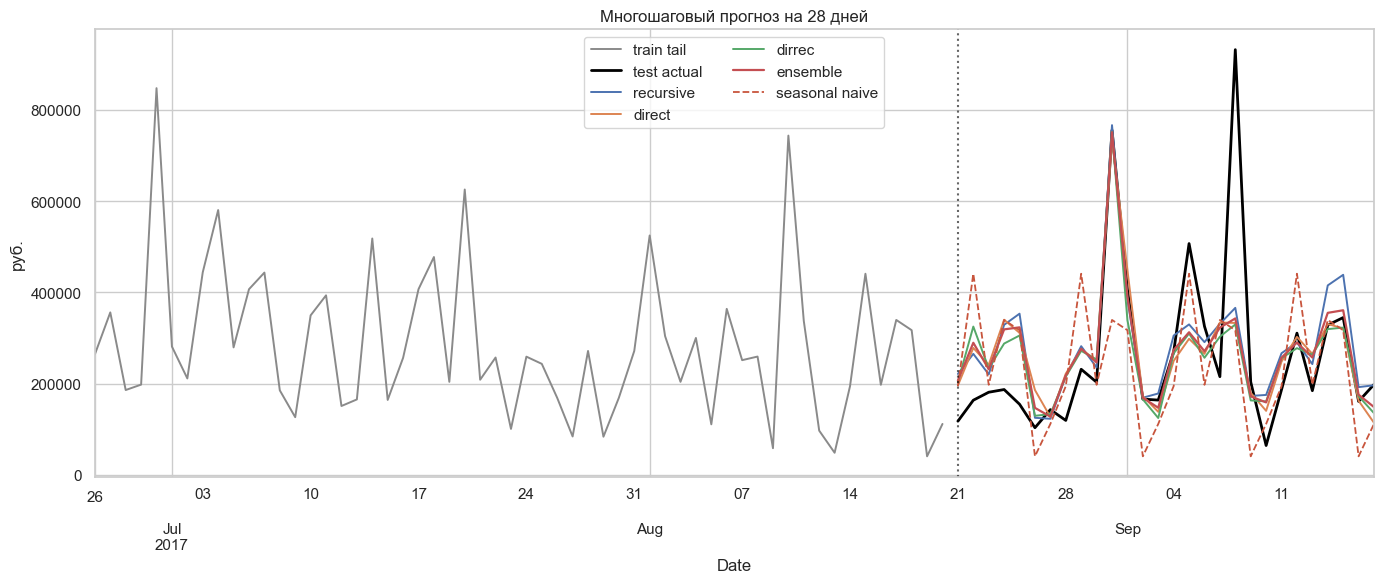

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))
multi_train_y.iloc[-2 * HORIZON :].plot(ax=ax, color="#8A8A8A", lw=1.4, label="train tail")
multi_test_y.plot(ax=ax, color="black", lw=2.0, label="test actual")
recursive_pred.plot(ax=ax, lw=1.4, label="recursive")
direct_pred.plot(ax=ax, lw=1.4, label="direct")
dirrec_pred.plot(ax=ax, lw=1.4, label="dirrec")
ensemble_pred.plot(ax=ax, lw=1.6, label="ensemble")
multi_naive.plot(ax=ax, color="#C8553D", lw=1.3, ls="--", label="seasonal naive")
ax.axvline(multi_test_y.index[0], color="black", ls=":", alpha=0.6)
ax.set_title("Многошаговый прогноз на 28 дней")
ax.set_ylabel("руб.")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

## Выводы

1. Ряд дневной, без пропусков, с выраженной недельной сезонностью и дополнительной календарной структурой около 4 недель. Сильного глобального тренда нет, поэтому основная прогнозная информация находится в лагах, окнах и календаре.
2. В одношаговом прогнозе `ExtraTrees` превосходит сезонный наивный бенчмарк, потому что использует больше информации, чем один лаг `7`.
3. В многошаговом прогнозе лучшая стратегия определяется по таблице WAPE выше. В моём запуске ML-стратегии также побивают сезонный наивный прогноз. Самый устойчивый результат обычно дают direct/DirRec или их ансамбль: они меньше зависят от одного рекурсивного пути, хотя требуют обучать больше моделей.
4. Погодные признаки добавлены осознанно по месту банкомата. Для горизонта 28 дней использована прогнозная климатология, чтобы не использовать фактическую будущую погоду из тестового периода.